## What is the Random Walker?

A population random walk models transport by moving walkers between states.
Each walker chooses its next state using a transition matrix `P`, where `P[i, j]`
is the probability of moving from state `i` to state `j`. The expected population follows

$$\mathbb{E}[n_{k+1}] = \mathbb{E}[n_k]P.$$

Here we use the same two-direction transport example as the Fugu RandomWalker
tutorial. Particles keep their direction, scatter, or are absorbed. Sango builds
the spiking circuit and Brian2 runs it. Counting readout spikes gives the population
in each state, which we compare with the discrete expectation and continuous solution.

[1] J. D. Smith et al., "Neuromorphic scaling advantages for energy-efficient random
walk computations," Nature Electronics 5, 102-112 (2022).
DOI: 10.1038/s41928-021-00705-7 (Supplementary Note 3.8).

## Setup

Import the libraries and define the problem. We start with 300 positive-direction
walkers and 180 negative-direction walkers. One walker represents 1/60 of a flux
unit, giving initial fluxes of 5 and 3. Use nonnegative integer counts.

The matrix rows represent positive direction, negative direction, and loss.
The loss row is zero: walkers are counted there once, then removed on the next
transition. `p_event` is the probability of exactly one event during `dt`;
half of scattering events change direction.

<details>
<summary>Installation</summary>

Use Python 3.13 and Git. Run these commands in the folder containing the notebook.
They install the package versions used for this example.

**Windows PowerShell:**

```powershell
py -3.13 -m venv .venv
.\.venv\Scripts\python.exe -m pip install "sango @ git+https://github.com/sandialabs/Sango.git@9585bcc2ed686e86ca9dc7bca544f4feba5c0a11" "Brian2==2.10.1" "numpy==2.5.3" "matplotlib==3.11.1" "scipy==1.18.1" "networkx==3.6.1" "PyYAML==6.0.3" "jupyterlab==4.6.4" "ipykernel==7.3.0" "ipython==9.17.1"
.\.venv\Scripts\python.exe -m jupyterlab random_walker_brian2_tutorial.ipynb
```

**macOS / Linux:**

```bash
python3.13 -m venv .venv
.venv/bin/python -m pip install "sango @ git+https://github.com/sandialabs/Sango.git@9585bcc2ed686e86ca9dc7bca544f4feba5c0a11" "Brian2==2.10.1" "numpy==2.5.3" "matplotlib==3.11.1" "scipy==1.18.1" "networkx==3.6.1" "PyYAML==6.0.3" "jupyterlab==4.6.4" "ipykernel==7.3.0" "ipython==9.17.1"
.venv/bin/python -m jupyterlab random_walker_brian2_tutorial.ipynb
```

Select this environment's Python kernel, then choose **Restart Kernel and Run All Cells**.

</details>

In [1]:
import contextlib
import io
import math
import numpy as np
import matplotlib.pyplot as plt
import brian2 as b2
from IPython.display import Markdown, display
from sango.backend import SimBrian
from sango import EdgeGroup, Network, NodeGroup, NodeList
from sango.model import LIF, PSP, pLIF

%matplotlib inline
np.set_printoptions(precision=6, suppress=True)

# Problem parameters
scattering = 8.0
absorption = 2.0
dt = 0.005
initial = np.array([300, 180, 0])
seed = 0
ticks = 80_000
flux_per_walker = 1 / 60

# Transition probabilities
rate = scattering + absorption
p_event = rate * dt * np.exp(-rate * dt)
if rate == 0:
    p_flip = 0.0
    p_loss = 0.0
else:
    p_flip = p_event * scattering / (2 * rate)
    p_loss = p_event * absorption / rate
p_stay = 1 - p_flip - p_loss

transport_P = np.array([
    [p_stay, p_flip, p_loss],  # Positive direction
    [p_flip, p_stay, p_loss],  # Negative direction
    [0.0, 0.0, 0.0],         # Loss
])
P = transport_P.copy()  # Set P and initial here for a different model.
print("Transition matrix (rows = from, columns = to):")
P

Transition matrix (rows = from, columns = to):


array([[0.971463, 0.019025, 0.009512],
       [0.019025, 0.971463, 0.009512],
       [0.      , 0.      , 0.      ]])

## Compute the Reference Solution

The discrete expectation updates by `n[k + 1] = n[k] @ P`. Actual walker counts
fluctuate around this average.

The continuous transport solution has two exponential terms: the total flux
decays at the absorption rate, and the difference between directions decays
at the sum of the scattering and absorption rates. The discrete and continuous
solutions differ slightly because `dt` is finite.

In [2]:
def analytic_flux(t):
    """Continuous transport prediction: one column for each direction."""
    initial_total = (initial[0] + initial[1]) * flux_per_walker
    initial_difference = (initial[0] - initial[1]) * flux_per_walker
    total = initial_total * np.exp(-absorption * t)
    difference = initial_difference * np.exp(-(absorption + scattering) * t)
    positive_flux = (total + difference) / 2
    negative_flux = (total - difference) / 2
    return np.column_stack((positive_flux, negative_flux))

# The continuous formula only applies to the transport matrix above.
is_transport = P.shape == transport_P.shape and np.allclose(P, transport_P, rtol=0, atol=1e-12)
print("Expected counts after one transition:", initial @ P)

Expected counts after one transition: [294.863361 180.570738   4.565901]


## Build the Neural Circuit

Each state is a `Room`. Its counter stores the population as a negative voltage.
A generator produces pulses, a readout reports one spike per walker, and random
gates choose the destinations. Buffers hold arrivals until the next step.

For three walkers, the counter starts at -3. The generator produces four pulses;
the counter cancels the extra readout and routing pulse, leaving three walkers.
For destination probabilities `[0.2, 0.3, 0.5]`, the gates use `0.2` and
`0.3 / 0.8`. The last destination is chosen if both gates fail.

`RandomWalker` connects the rooms. Four controllers start the walk, wait for
routing to finish, start buffer copying, and wait for copying to finish before
the next step. The definitions are included here so the notebook runs on its own.

In [3]:
def edge(source, target, weight=1.0, delay=1, pair=(0, 0)):
    """Connect one source neuron to one target neuron."""
    connection = PSP(weight=float(weight), delay=float(delay))
    return EdgeGroup(source, target, connection, edges=[pair])

In [4]:
class Room(Network):
    """One room stores a count and reports one spike per walker."""
    def __init__(self, neighbours, population):
        super().__init__()
        self.neighbours = tuple(neighbours)
        self.population = population
        # Keep one gate for zero/one destinations to retain the same timing.
        self.num_gates = max(len(self.neighbours) - 1, 1)

    def build(self):
        # leak=0 stores voltage; leak=1 clears it each tick.
        self.counter = NodeGroup(LIF(threshold=0.5, leak=0.0), 1, voltage=-float(self.population))
        self.generator = NodeGroup(LIF(threshold=0.5, leak=1.0), 1)
        self.readout = NodeGroup(LIF(threshold=0.5, leak=0.0), 1)
        self.buffer = NodeGroup(LIF(threshold=0.5, leak=0.0), 1)
        self.buffer_control = NodeGroup(LIF(threshold=0.5, leak=1.0), 1)

        # Choose a destination using the probabilities still available.
        probabilities = [probability for _, probability in self.neighbours]
        if not probabilities:
            probabilities = [0.0]
        self.random_gates = []
        for j in range(self.num_gates):
            # Try this destination only if earlier choices failed.
            remaining = math.fsum(probabilities[j:])
            if remaining == 0:
                conditional_probability = 0.0
            else:
                conditional_probability = probabilities[j] / remaining
            gate_model = pLIF(threshold=0.5, leak=1.0, prob=conditional_probability)
            self.random_gates.append(NodeGroup(gate_model, 1))
        self.output_gates = NodeGroup(LIF(threshold=0.5, leak=1.0), self.num_gates + 1)

        self.edges = []
        # The counter cancels the extra generator pulse and stops the loop.
        for source, target, weight in [
            (self.generator, self.generator, 1), (self.generator, self.counter, 1),
            (self.generator, self.readout, 1), (self.counter, self.generator, -1),
            (self.counter, self.counter, -1), (self.counter, self.readout, -1),
            # Copy buffered arrivals into the counter after routing finishes.
            (self.buffer_control, self.counter, -1),
            (self.buffer_control, self.buffer_control, 1),
            (self.buffer_control, self.buffer, 1), (self.buffer, self.counter, 1),
            (self.buffer, self.buffer_control, -1), (self.buffer, self.buffer, -1),
        ]:
            self.edges.append(edge(source, target, weight))

        # Delays align each walker's excitation and inhibition.
        for j, gate in enumerate(self.random_gates):
            self.edges += [edge(self.generator, gate, 1, j + 1),
                           edge(self.counter, gate, -1, j + 1),
                           edge(gate, self.output_gates, 1, pair=(0, j))]
            for later in range(j + 1, self.num_gates):
                self.edges.append(edge(gate, self.random_gates[later], -1, later - j))
            self.edges.append(edge(gate, self.output_gates, -1, self.num_gates - j,
                                   pair=(0, self.num_gates)))
        # The final output fires unless an earlier gate cancels it.
        self.edges += [edge(self.generator, self.output_gates, 1, self.num_gates + 1,
                            pair=(0, self.num_gates)),
                       edge(self.counter, self.output_gates, -1, self.num_gates + 1,
                            pair=(0, self.num_gates))]

In [5]:
class RandomWalker(Network):
    """Connect the rooms and control when each walk and buffer copy begins."""
    def __init__(self, matrix, initial, timer_ticks=80000):
        super().__init__()
        self.P = np.array(matrix, dtype=float, copy=True)
        if self.P.ndim != 2 or self.P.shape[0] != self.P.shape[1] or not len(self.P):
            raise ValueError("matrix must be a nonempty square 2-D array")
        if not np.all(np.isfinite(self.P)) or np.any(self.P < 0):
            raise ValueError("matrix entries must be finite and nonnegative")
        row_sums = self.P.sum(axis=1)
        has_outgoing = np.any(self.P > 0, axis=1)
        if np.any(has_outgoing & ~np.isclose(row_sums, 1., rtol=0, atol=1e-12)):
            raise ValueError("each nonzero matrix row must sum to one; add an explicit loss room")
        self.P[has_outgoing] /= row_sums[has_outgoing, None]
        # Each room starts with a nonnegative whole number of walkers.
        self.initial = np.asarray(initial)
        if self.initial.shape != (len(self.P),):
            raise ValueError("initial must contain one count per room")
        if not np.issubdtype(self.initial.dtype, np.integer) or np.any(self.initial < 0):
            raise ValueError("initial counts must be nonnegative integers")
        # Very large counts would exceed the voltage's exact integer range.
        if sum(int(x) for x in self.initial) >= 2**52:
            raise ValueError("total population must be below 2**52")
        self.initial = self.initial.astype(np.int64)
        if int(timer_ticks) != timer_ticks or timer_ticks < 1:
            raise ValueError("timer_ticks must be a positive whole number")
        self.timer_ticks = int(timer_ticks)

        rooms = []
        for row, population in zip(self.P, self.initial):
            neighbours = []
            for destination, probability in enumerate(row):
                if probability > 0:
                    neighbours.append((destination, float(probability)))
            rooms.append(Room(neighbours, int(population)))
        self.rooms = rooms

    def build(self):
        # Four controllers separate walking from copying arrivals.
        n = len(self.P)
        self.walker_supervisor = NodeGroup(LIF(threshold=1., leak=1.0), 1, voltage=10.)
        self.walks_complete = NodeGroup(LIF(threshold=n - .5, leak=0.0), 1)
        self.buffer_supervisor = NodeGroup(LIF(threshold=1., leak=1.0), 1)
        self.buffer_clear = NodeGroup(LIF(threshold=n - .5, leak=0.0), 1)
        # Use child settings now; Sango resolves their neuron paths during build.
        children = self._children["rooms"]
        paths = [self.rooms[i] for i in range(n)]
        self.edges = []
        for child, path in zip(children, paths):
            self.edges += [edge(self.walker_supervisor, path.counter),
                           edge(self.walker_supervisor, path.generator),
                           edge(path.counter, self.walks_complete, 1, child.num_gates + 1),
                           edge(self.buffer_supervisor, path.buffer),
                           edge(self.buffer_supervisor, path.buffer_control),
                           edge(path.buffer, self.buffer_clear)]
        for child, path in zip(children, paths):
            for gate_index, (destination, _) in enumerate(child.neighbours):
                self.edges.append(edge(path.output_gates, paths[destination].buffer, -1,
                                       pair=(gate_index, 0)))
        # Weight 2 exceeds the supervisor threshold of 1.
        self.edges += [edge(self.walks_complete, self.buffer_supervisor, 2, 2),
                       edge(self.buffer_clear, self.walker_supervisor, 2, 2)]
        self.readout = NodeList([path.readout[0] for path in paths])

        # With Brian's > test, timer_ticks - 0.5 fires after timer_ticks inputs.
        # This clock is diagnostic; sim.run(ticks) controls the run length.
        self.timer = NodeGroup(LIF(threshold=0.5, leak=0.0), 1, voltage=1.)
        self.timer_complete = NodeGroup(LIF(threshold=self.timer_ticks - .5, leak=0.0), 1)
        self.edges += [edge(self.timer, self.timer), edge(self.timer, self.timer_complete)]
        self.complete = NodeList([self.timer_complete[0]])

In [6]:
b2.start_scope()
b2.prefs.codegen.target = "numpy"
with contextlib.redirect_stdout(io.StringIO()):  # Hide routine construction messages.
    net = RandomWalker(P, initial, timer_ticks=ticks)
    net.build()
P, initial = net.P.copy(), net.initial.copy()  # Validated inputs.

## Compile to the Brian2 Backend

`SimBrian` translates the Sango network into Brian2 neurons, synapses, and spike
monitors. We use Brian's NumPy runtime to run the circuit on the CPU.

In [7]:
sim = SimBrian(net)
sim.compile()
assert float(sim.tstep / b2.ms) == 1.0
print(f"{sim.num_nodes} neurons, {sim.ref_graph.number_of_edges()} synapses")

34 neurons, 92 synapses


## Run the Simulation

Run the circuit for `ticks` time steps. One circuit tick is 1 Brian millisecond.
A walker step takes several circuit ticks and represents `dt` units of physical
time. The seed makes the run repeatable in this environment.

In [8]:
b2.seed(seed)
sim.run(ticks)
spike_count = sum(int(m.num_spikes) for m in sim.spike_monitors.values())
print(f"Executed {ticks:,} ticks; recorded {spike_count:,} spikes")

Executed 80,000 ticks; recorded 377,131 spikes


## Analyze Results

`node_ticks` reads the spike times for a Sango neuron from its Brian monitor.
`decode_rounds` counts readout spikes between `walks_complete` events, giving
one population row per complete model state (a census). The first row is the initial
population at physical time zero. An unfinished final row is reported separately.

For example, readouts at `[2, 3, 4, 17]` with completion times `[6, 21]` give
counts `[3, 1]`. We also calculate the discrete expectation by repeated matrix
multiplication; these values are only a comparison and do not drive the circuit.

In [9]:
def node_ticks(sim, node):
    """Return the circuit ticks when this Sango neuron fired."""
    original_index = sim.node_index[node.name]
    group_name = sim.node_data[original_index]["group_name"]
    local_index = sim.local_index[original_index]
    monitor = sim.spike_monitors[group_name]

    # Select this neuron's events from its Brian group's spike recorder.
    is_this_neuron = np.asarray(monitor.i) == local_index
    times_in_seconds = np.asarray(monitor.t_)[is_this_neuron]
    seconds_per_tick = float(sim.tstep / b2.second)
    tick_values = times_in_seconds / seconds_per_tick

    rounded = np.rint(tick_values)
    if not np.allclose(tick_values, rounded, rtol=0, atol=1e-8):
        raise RuntimeError("off-grid Brian timestamp: check timestep/delay semantics")
    return rounded.astype(np.int64)

In [10]:
def decode_rounds(net, sim):
    """Read complete populations and keep an unfinished population separate."""
    completions = node_ticks(sim, net.walks_complete[0])
    starts = node_ticks(sim, net.walker_supervisor[0])
    readouts = [node_ticks(sim, node) for node in net.readout]

    # Each completion ends one full population count.
    counts = np.zeros((len(completions), len(net.P)), dtype=np.int64)
    for room_index, spikes in enumerate(readouts):
        cumulative = np.searchsorted(spikes, completions, side="right")
        counts[:, room_index] = np.diff(cumulative, prepend=0)

    # Zero-row rooms record walkers that leave the network.
    has_outgoing = np.any(net.P > 0, axis=1)
    live = counts[:, has_outgoing].sum(axis=1)
    loss = counts[:, ~has_outgoing].sum(axis=1)
    absorbed = np.cumsum(loss)

    # A start without a completion means the last population is unfinished.
    partial = None
    if len(starts) > len(completions):
        last_completion = completions[-1] if len(completions) else -1
        partial = np.array([np.count_nonzero(spikes > last_completion) for spikes in readouts])

    return {"counts": counts, "live": live, "absorbed": absorbed, "partial": partial}

In [11]:
decoded = decode_rounds(net, sim)
counts = decoded["counts"]
if not len(counts):
    raise ValueError("Increase ticks: no complete census was recorded.")
assert np.array_equal(counts[0], initial), "The first population must match the starting counts."

# Compare the spike counts with the average predicted by P.
t = np.arange(len(counts)) * dt
expected = np.empty_like(counts, dtype=float)
expected[0] = initial
for k in range(1, len(counts)):
    expected[k] = expected[k - 1] @ P

print(f"{len(counts):,} complete populations")
print("Unfinished population:", decoded["partial"])
print("First five censuses (one column per room):")
counts[:5]

2,388 complete populations
Unfinished population: None
First five censuses (one column per room):


array([[300, 180,   0],
       [294, 182,   4],
       [292, 179,   5],
       [279, 185,   7],
       [273, 185,   6]])

## Plot the Results

Solid lines show the simulated flux, dashed lines the discrete expectation,
and dotted lines the continuous solution. The right panel checks that live
walkers plus cumulative loss equal the initial population.

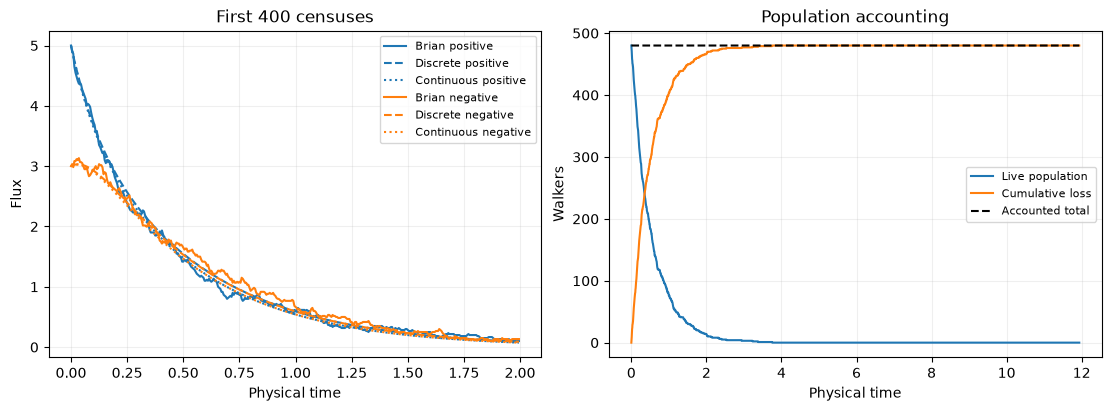

In [12]:
view = min(len(counts), 400)
scale = flux_per_walker if is_transport else 1.0
rooms = range(2) if is_transport else range(len(P))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for j in rooms:
    label = ["positive", "negative"][j] if is_transport else f"room {j}"
    color = plt.get_cmap("tab10")(j % 10)
    axes[0].plot(t[:view], counts[:view, j] * scale, color=color, label=f"Brian {label}")
    axes[0].plot(t[:view], expected[:view, j] * scale, color=color, ls="--", label=f"Discrete {label}")
    if is_transport:
        axes[0].plot(t[:view], analytic_flux(t[:view])[:, j], color=color, ls=":", label=f"Continuous {label}")
axes[0].set(title=f"First {view} censuses", xlabel="Physical time", ylabel="Flux" if is_transport else "Walkers")

# Every walker must be either live or recorded as lost.
axes[1].plot(t, decoded["live"], label="Live population")
axes[1].plot(t, decoded["absorbed"], label="Cumulative loss")
axes[1].plot(t, (decoded["live"] + decoded["absorbed"]), "k--", label="Accounted total")
axes[1].set(title="Population accounting", xlabel="Physical time", ylabel="Walkers")
for ax in axes:
    for line in ax.lines:
        if len(line.get_xdata()) == 1:
            line.set_marker("o")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
plt.show()

## Reference Comparison

Check that live walkers plus cumulative loss equal the starting population.
This total must match exactly. Individual room counts vary because the walks
are random, so we report their difference from the expected counts.

For the transport example, we also report two average flux differences:
the simulation versus the discrete expectation, and the discrete expectation
versus the continuous solution.

In [13]:
# Population is conserved when recorded losses are included.
assert np.all(decoded["live"] + decoded["absorbed"] == initial.sum()), "Population accounting failed."
print("Population accounting: PASS")

# Report the difference from the average; random counts need not match it exactly.
max_error = np.abs(counts - expected).max()
print(f"Largest difference from expected counts: {max_error:.3f} walkers")
if is_transport:
    sampling_error = np.abs(counts[:view, :2] - expected[:view, :2]).mean() * flux_per_walker
    model_error = np.abs(expected[:view, :2] * flux_per_walker - analytic_flux(t[:view])).mean()
    print(f"Mean simulation difference: {sampling_error:.6f} flux units")
    print(f"Mean discrete-to-continuous difference: {model_error:.6f} flux units")

Population accounting: PASS
Largest difference from expected counts: 15.636 walkers
Mean simulation difference: 0.065899 flux units
Mean discrete-to-continuous difference: 0.041690 flux units


## Summary Table

Change the initial counts, seed, tick budget, or transition matrix in **Setup**,
then restart and run all cells. A custom matrix uses only the discrete reference.

In [14]:
summary = {
    "Neurons / synapses": f"{sim.num_nodes} / {sim.ref_graph.number_of_edges()}",
    "Circuit ticks": ticks,
    "Complete censuses": len(counts),
    "Initial walkers": int(initial.sum()),
    "Final live": int(decoded["live"][-1]),
    "Cumulative loss": int(decoded["absorbed"][-1]),
    "Largest count difference": f"{max_error:.3f}",
    "Population accounting": "PASS",
}
table = "| Result | Value |\n|---|---|\n"
for name, value in summary.items():
    table += f"| {name} | {value} |\n"
display(Markdown(table))

| Result | Value |
|---|---|
| Neurons / synapses | 34 / 92 |
| Circuit ticks | 80000 |
| Complete censuses | 2388 |
| Initial walkers | 480 |
| Final live | 0 |
| Cumulative loss | 480 |
| Largest count difference | 15.636 |
| Population accounting | PASS |
